# Project Overview

**Portfolio-Inspired Inventory Optimization**

**Course:** MSML 604 - Introduction to Optimization, Spring 2026

**Group:** 22 | **Author:** Keegan Sanctis | **UID:** 122067684

University of Maryland, College Park

---

This notebook implements a portfolio-inspired convex optimization framework for multi-item inventory management, applied to real sales and purchase data from RoyalTech Electrical & Contracting Co., a retail business based in Kuwait specializing in low-to-medium voltage electrical components.

The project adapts the Markowitz mean-variance portfolio optimization framework to the inventory allocation problem, treating each SKU as an asset where expected demand plays the role of expected return and demand variability captures stockout risk. The objective is to minimize total inventory cost - comprising holding costs and expected stockout losses - subject to a capital budget constraint, formulated and solved as a convex optimization problem using CVXPY.

---

**Dataset:** ~3,856 active SKUs | 13-15 years of sales history | 278,763 sales transactions

**Solver:** CVXPY (CLARABEL)

**Key Result:** 22.61% cost reduction over uniform baseline allocation

# Setup & Imports

In [1]:
# Importing necessary packages
!pip install cvxpy -q
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
import numpy as np
import shutil
from scipy.stats import norm

# Data Loading

In [2]:
# File paths
sales_path = '/content/drive/MyDrive/UMD Spring-26/MSML 604/Project/sales_data.xlsx'
purchase_path = '/content/drive/MyDrive/UMD Spring-26/MSML 604/Project/purchase_data.xlsx'

# Loading data
print("Loading sales data...")
sales_df = pd.read_excel(sales_path)
print(f"Sales Data Loaded: {sales_df.shape[0]} rows, {sales_df.shape[1]} columns")

print("\nLoading purchase data...")
purchase_df = pd.read_excel(purchase_path)
print(f"Purchase Data Loaded: {purchase_df.shape[0]} rows, {purchase_df.shape[1]} columns")

# Renaming column names
sales_df.columns = ['sku_code', 'product_name', 'is_free', 'qty_sold', 'unit_price', 'discount', 'is_canceled', 'date', 'unit', 'cost_price']
purchase_df.columns = ['sku_code', 'product_name', 'is_free', 'qty_purchased', 'is_canceled', 'date', 'unit', 'landed_cost']

# Viewing sample data
print("\n--- Sales Data Sample ---")
print(sales_df.head())

print("\n--- Purchase Data Sample ---")
print(purchase_df.head())

Loading sales data...
Sales Data Loaded: 287905 rows, 10 columns

Loading purchase data...
Purchase Data Loaded: 103545 rows, 8 columns

--- Sales Data Sample ---
  sku_code                     product_name  is_free  qty_sold  unit_price  \
0   100019  ADAPTOR BRASS MALE W/LNT 1 1/2"        0       2.0        0.85   
1   100019  ADAPTOR BRASS MALE W/LNT 1 1/2"        0       1.0        0.75   
2   100019  ADAPTOR BRASS MALE W/LNT 1 1/2"        0     200.0        0.50   
3   100019  ADAPTOR BRASS MALE W/LNT 1 1/2"        0     250.0        0.60   
4   100019  ADAPTOR BRASS MALE W/LNT 1 1/2"        0     150.0        0.50   

   discount is_canceled      date unit  cost_price  
0       0.0           F  20210202   EA       0.400  
1       0.0           F  20180317   EA       0.450  
2       0.0           F  20180402   EA       0.450  
3       0.0           F  20210922   EA       0.366  
4       0.0           F  20170417   EA       0.400  

--- Purchase Data Sample ---
   sku_code         

# Data Quality Check

In [3]:
print("--- Sales Data Info ---\n")
print(sales_df.info())
print(f"\nNull Values (Sales Data):")
print(sales_df.isnull().sum())

print("\n--- Purchase Data Info ---\n")
print(purchase_df.info())
print(f"\nNull Values (Purchase Data):")
print(purchase_df.isnull().sum())

--- Sales Data Info ---

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287905 entries, 0 to 287904
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   sku_code      287905 non-null  object 
 1   product_name  287905 non-null  object 
 2   is_free       287905 non-null  int64  
 3   qty_sold      287905 non-null  float64
 4   unit_price    287905 non-null  float64
 5   discount      287905 non-null  float64
 6   is_canceled   287905 non-null  object 
 7   date          287905 non-null  int64  
 8   unit          287905 non-null  object 
 9   cost_price    287905 non-null  float64
dtypes: float64(4), int64(2), object(4)
memory usage: 22.0+ MB
None

Null Values (Sales Data):
sku_code        0
product_name    0
is_free         0
qty_sold        0
unit_price      0
discount        0
is_canceled     0
date            0
unit            0
cost_price      0
dtype: int64

--- Purchase Data Info ---

<class 'pandas.core

# Data Preprocessing

The raw data is cleaned and prepared through the following steps:

*   **Date conversion:** The 'date' column in both files is stored as an integer in 'YYYYMMDD' format and is converted to a proper datetime format for time-series aggregation
*   **Filtering canceled transactions:** Rows where 'is_canceled' = 'T' are removed from both files as they do not represent real completed transactions
*   **Filtering free items:** Rows where 'is_free' = 1 are removed as they do not reflect actual paid demand and would distort demand structure
*   **SKU code normalization:** The 'sku_code' column is stored as 'object' in the sales file and 'int64' in the purchase file, both are converted to string to ensure consistent joining across the two datasets





In [4]:
# Converting date columns to datetime
sales_df['date'] = pd.to_datetime(sales_df['date'], format='%Y%m%d')
purchase_df['date'] = pd.to_datetime(purchase_df['date'], format='%Y%m%d')

sales_df['date'] = sales_df['date'].dt.date
purchase_df['date'] = purchase_df['date'].dt.date

sales_df['date'] = pd.to_datetime(sales_df['date'])
purchase_df['date'] = pd.to_datetime(purchase_df['date'])

# Filtering our canceled and free transactions
sales_df = sales_df[(sales_df['is_canceled'] == 'F') & (sales_df['is_free'] == 0)]
purchase_df = purchase_df[(purchase_df['is_canceled'] == 'F') & (purchase_df['is_free'] == 0)]

# Normalizing sku_code type to string
sales_df['sku_code'] = sales_df['sku_code'].astype(str)
purchase_df['sku_code'] = purchase_df['sku_code'].astype(str)

# Confirming results
print(f"Sales data rows after filtering: {len(sales_df)}")
print(f"Purchase data rows after filtering: {len(purchase_df)}")
print(f"\nSales date range: {sales_df['date'].min()} to {sales_df['date'].max()}")
print(f"Purchase date range: {purchase_df['date'].min()} to {purchase_df['date'].max()}")

Sales data rows after filtering: 278763
Purchase data rows after filtering: 102907

Sales date range: 2011-09-03 00:00:00 to 2026-05-02 00:00:00
Purchase date range: 2011-08-21 00:00:00 to 2026-04-30 00:00:00


# Exploratory Data Analysis

No. of unique SKUs in sales data: 15955
No. of unique SKUs in purchase data: 16196
SKUs common to both sales and purchase: 15473


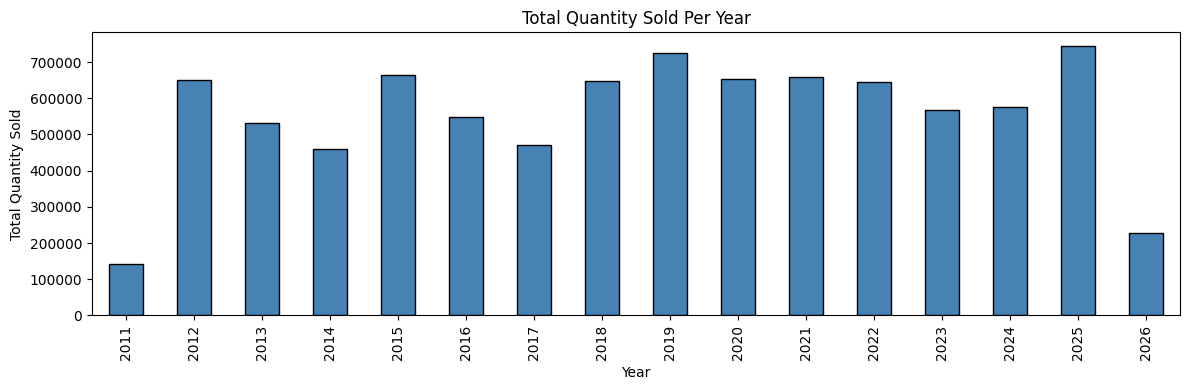

In [5]:
# Checking SKU coverage
sales_skus = sales_df['sku_code'].nunique()
purchase_skus = purchase_df['sku_code'].nunique()
print(f"No. of unique SKUs in sales data: {sales_skus}")
print(f"No. of unique SKUs in purchase data: {purchase_skus}")

# Checking SKUs common to both sales and purchase
common_skus = set(sales_df['sku_code'].unique()) & set(purchase_df['sku_code'].unique())
print(f"SKUs common to both sales and purchase: {len(common_skus)}")

# Calculating sales transanctions per year
sales_df['year'] = sales_df['date'].dt.year
yearly_sales = sales_df.groupby('year')['qty_sold'].sum()

plt.figure(figsize=(12, 4))
yearly_sales.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Total Quantity Sold Per Year")
plt.xlabel("Year")
plt.ylabel("Total Quantity Sold")
plt.tight_layout()
plt.show()

Initial exploration reveals 15,955 unique SKUs in the sales data and 16,196 in the purchase data which is significantly more than the 3,000-4,000 SKUs physically held in active inventory.

This is expected, as the dataset spans 15 years and includes discontinued products, one-off purchases, and items that were sold only a handful of times before being phased out.

To focus the optimization on currently active and relevant inventory, SKUs are filtered using the following criteria:

*   **Recency:** SKU must have at least one sale between 2020 and 2026, reflecting the current market and product availability
*   **Minimum activity:** SKU must have at least 5 transactions within the 2020-2026 window to ensure sufficient demand history
*   **Temporal coverage:** SKU must appear in at least 3 distinct years within the window to ensure demand estimates are not driven by a single year
*   **Cost availability:** SKU must appear in the purchase data with a valid landed cost (>= 0.001 KWD) to ensure procurement cost is available for the budget constraint

This filtering reduces the dataset to **3,856 active SKUs**, closely matching the physical inventory count at RoyalTech Electrical & Contracting Co.





In [6]:
# Filtering sales data to 2020-2026 to depict current market situation
sales_recent = sales_df[sales_df['date'].dt.year >= 2020].copy()

# Counting transactions and unique years per SKU
sku_stats = sales_recent.groupby('sku_code').agg(
    transaction_count=('qty_sold', 'count'),
    unique_years=('date', lambda x: x.dt.year.nunique())
).reset_index()

# Filtering the active SKUs
active_skus = sku_stats[
    (sku_stats['transaction_count'] >= 5) &
    (sku_stats['unique_years'] >= 3)
]['sku_code'].values

active_skus = [sku for sku in active_skus if sku in set(purchase_df['sku_code'].unique())]
print(f"Active SKUs after filtering: {len(active_skus)}")

# Filtering both dataframes to active SKUs only
sales_active = sales_df[sales_df['sku_code'].isin(active_skus)].copy()
purchase_active = purchase_df[purchase_df['sku_code'].isin(active_skus)].copy()
print(f"Sales data rows for active SKUs: {len(sales_active)}")
print(f"Purchase data rows for active SKUs: {len(purchase_active)}")

Active SKUs after filtering: 3858
Sales data rows for active SKUs: 218429
Purchase data rows for active SKUs: 67836


# Demand & Cost Parameter Estimation

The mean-variance framework requires two key demand parameters per SKU - the expected demand (mean) and the demand variability (variance) - along with a procurement cost estimate. These are computed as follows:
*   **Monthly demand aggregation:** Transaction level sales data is aggregated to monthly totals per SKU, producing a time series of monthly demand for each item across the 2020-2026 window
*   **Mean demand:** The average monthly quantity sold per SKU, representing the expected demand the optimizer targets when allocating stock
*   **Demand variance:** The variance of monthly quantity sold per SKU, capturing demand unpredictability and stock risk, analogous to asset risk in the Markowitz framework
*   **Average landed cost:** The mean landed cost per unit across all purchase transactions for each SKU, used as the unit procurement cost in the budget constraint

These parameters are consolidated into a main dataframe of 3,856 SKUs which serves as the direct input to the CVXPY optimization model.





In [7]:
# Aggregating monthly demand per SKU using full sales history for active SKUs
sales_active['year_month'] = sales_active['date'].dt.to_period('M')

monthly_demand = sales_active.groupby(['sku_code', 'year_month'])['qty_sold'].sum().reset_index()
monthly_demand.columns = ['sku_code', 'year_month', 'monthly_qty']

# Computing mean and variance of monthly demand per SKU
demand_parameters = monthly_demand.groupby('sku_code')['monthly_qty'].agg(
    mean_demand='mean',
    variance_demand='var'
).reset_index()

demand_parameters['std_demand'] = demand_parameters['variance_demand'] ** 0.5

print(f"--- Demand parameters computed for {len(demand_parameters)} SKUs ---")
print(demand_parameters.describe())

# Computing average landed cost per SKU from purchase data
cost_parameters = purchase_active.groupby('sku_code')['landed_cost'].agg(
    avg_landed_cost='mean'
).reset_index()

print(f"\n--- Cost parameters computed for {len(cost_parameters)} SKUs ---")
print(cost_parameters.describe())

--- Demand parameters computed for 3858 SKUs ---
       mean_demand  variance_demand   std_demand
count  3858.000000     3.858000e+03  3858.000000
mean     41.510926     6.018951e+04    67.713316
std     120.444279     8.638911e+05   235.836459
min       1.000000     0.000000e+00     0.000000
25%       5.000000     2.721806e+01     5.217093
50%      12.559908     2.283170e+02    15.110161
75%      33.000000     2.035324e+03    45.114530
max    2870.379310     4.189727e+07  6472.810382

--- Cost parameters computed for 3858 SKUs ---
       avg_landed_cost
count      3858.000000
mean          3.337479
std           8.065727
min           0.000000
25%           0.394158
50%           1.000000
75%           3.091170
max         167.494444


In [8]:
# Checking zero and near zero cost SKUs for further filtering
zero_cost = cost_parameters[cost_parameters['avg_landed_cost'] == 0]
print(f"SKUs with zero landed cost: {len(zero_cost)}")

near_zero_cost = cost_parameters[cost_parameters['avg_landed_cost'] < 0.001]
print(f"SKUs with landed cost < 0.001: {len(near_zero_cost)}")

# Dropping SKUs with zero landed cost only
valid_cost_skus = cost_parameters[cost_parameters['avg_landed_cost'] >= 0.001]['sku_code'].values

# Updating active SKUs list
active_skus = [sku for sku in active_skus if sku in set(valid_cost_skus)]
print(f"\nActive SKUs after removing zero cost SKUs: {len(active_skus)}")

# Refiltering both dataframes
sales_active = sales_active[sales_active['sku_code'].isin(active_skus)].copy()
purchase_active = purchase_active[purchase_active['sku_code'].isin(active_skus)].copy()
demand_parameters = demand_parameters[demand_parameters['sku_code'].isin(active_skus)].copy()
cost_parameters = cost_parameters[cost_parameters['sku_code'].isin(active_skus)].copy()

print(f"\nActive SKUs remaining: {len(active_skus)}")
print(f"Sales data rows: {len(sales_active)}")
print(f"Purchase data rows: {len(purchase_active)}")

SKUs with zero landed cost: 2
SKUs with landed cost < 0.001: 2

Active SKUs after removing zero cost SKUs: 3856

Active SKUs remaining: 3856
Sales data rows: 218383
Purchase data rows: 67834


In [9]:
# Merging demand and cost parameters into one main dataframe with product names
main_df = demand_parameters.merge(cost_parameters, on='sku_code', how='inner')
sku_names = sales_active[['sku_code', 'product_name']].drop_duplicates('sku_code')
main_df = main_df.merge(sku_names, on='sku_code', how='left')

# Reordering of columns in the main dataframe
main_df = main_df[['sku_code', 'product_name', 'mean_demand', 'variance_demand', 'std_demand', 'avg_landed_cost']]

print(f"Main dataframe shape: {main_df.shape}")
print("\n--- Sample data from main dataframe ---")
print(main_df.head(10))
print(f"\nNulls in main dataframe: {main_df.isnull().sum().sum()}")

Main dataframe shape: (3856, 6)

--- Sample data from main dataframe ---
  sku_code                     product_name  mean_demand  variance_demand  \
0   100019  ADAPTOR BRASS MALE W/LNT 1 1/2"    68.252874     1.287863e+04   
1   100020      ADAPTOR BRASS MALE W/LNT 1"    80.031496     1.391457e+04   
2   100021      ADAPTOR BRASS MALE W/LNT 2"    59.282051     3.348558e+04   
3   100022    ADAPTOR BRASS MALE W/LNT 20MM   130.040000     1.560730e+05   
4   100023    ADAPTOR BRASS MALE W/LNT 25MM    66.095238     8.762790e+03   
5   100024    ADAPTOR BRASS MALE W/LNT 3/4"   167.302632     6.585852e+04   
6   100027          ADAPTOR GI W/LNT 1 1/2"    47.300000     5.822456e+03   
7   100028              ADAPTOR GI W/LNT 1"   839.875000     3.420514e+06   
8   100030            ADAPTOR GI W/LNT 3/4"    63.219512     5.877276e+03   
9   100034      ADAPTOR KOPEX UK W/LNT 20MM    65.826087     3.367347e+03   

    std_demand  avg_landed_cost  
0   113.484065         0.430538  
1   117.960

In [10]:
# Defining holding cost and stockout penalty parameters
holding_cost_rate = 0.0208 # 25% annual / 12 months
stockout_penalty_multiplier = 1.5

main_df['holding_cost'] = holding_cost_rate * main_df['avg_landed_cost']
main_df['stockout_penalty'] = stockout_penalty_multiplier * main_df['avg_landed_cost']

print("--- Updated main dataframe ---")
print(main_df.head(10))
print(f"\nNulls in main dataframe: {main_df.isnull().sum().sum()}")

--- Updated main dataframe ---
  sku_code                     product_name  mean_demand  variance_demand  \
0   100019  ADAPTOR BRASS MALE W/LNT 1 1/2"    68.252874     1.287863e+04   
1   100020      ADAPTOR BRASS MALE W/LNT 1"    80.031496     1.391457e+04   
2   100021      ADAPTOR BRASS MALE W/LNT 2"    59.282051     3.348558e+04   
3   100022    ADAPTOR BRASS MALE W/LNT 20MM   130.040000     1.560730e+05   
4   100023    ADAPTOR BRASS MALE W/LNT 25MM    66.095238     8.762790e+03   
5   100024    ADAPTOR BRASS MALE W/LNT 3/4"   167.302632     6.585852e+04   
6   100027          ADAPTOR GI W/LNT 1 1/2"    47.300000     5.822456e+03   
7   100028              ADAPTOR GI W/LNT 1"   839.875000     3.420514e+06   
8   100030            ADAPTOR GI W/LNT 3/4"    63.219512     5.877276e+03   
9   100034      ADAPTOR KOPEX UK W/LNT 20MM    65.826087     3.367347e+03   

    std_demand  avg_landed_cost  holding_cost  stockout_penalty  
0   113.484065         0.430538      0.008955          

# Optimization Model

**Model Parameters & Assumptions**

The optimization model is built on the following parameters and assumptions:

*   **Budget:** Set to 50% of the total cost required to stock one full month of mean demand across all SKUs, equivalent to **66,507 KWD** (full stocking cost: 133,014 KWD)
*   **Holding Cost Rate:** 25% annually (2.08% monthly) of the average landed cost per unit - consistent with industry standard inventory carrying cost estimates
*   **Stockout Penalty:** 1.5 times the average landed cost per unit of unmet demand - representing lost margin and indirect customer relationship costs
*   **Demand Distribution:** Monthly demand per SKU is modeled using historical mean and standard deviation estimated from 2020-2026 sales data
*   **Solver:** CVXPY with the CLARABEL solver

**Key Assumption:** The model assumes inventory is allocated from scartch each month against a fixed budget. Current available stock levels are not incorporated as a lower bound constraint - this is acknowledged as a limitation and an extension for future work.







In [11]:
# Extracting optimization parameters as numpy arrays
n = len(main_df)
mean = main_df['mean_demand'].values
std = main_df['std_demand'].values
holding_cost = main_df['holding_cost'].values
stockout_penalty = main_df['stockout_penalty'].values
procurement_cost = main_df['avg_landed_cost'].values

# Defining budget and set 50% of cost
Budget = 0.5 * np.sum(procurement_cost * mean)
print(f"Number of SKUs: {n}")
print(f"Budget: {Budget:,.3f} KWD")
print(f"Full stocking cost: {np.sum(procurement_cost * mean):,.3f} KWD")

Number of SKUs: 3856
Budget: 66,507.315 KWD
Full stocking cost: 133,014.631 KWD


In [12]:
def solve_inventory_optimization(Budget):
  # Decision variable - quantity to stock for each SKU
  q = cp.Variable(n)

  # Expected stockout cost using the normal distribution approximation
  # This is done using a linearized newsvendor loss
  z = (mean - q) / (std + 1e-6)
  expected_shortfall = cp.multiply(std, cp.multiply(norm.pdf(0), cp.exp(-cp.square(z) / 2)) / norm.pdf(0))

  # Total cost objective
  holding = cp.sum(cp.multiply(holding_cost, q))
  stockout = cp.sum(cp.multiply(stockout_penalty, cp.pos(mean - q)))
  total_cost = holding + stockout

  # Optimization Constraints
  constraints = [
      cp.sum(cp.multiply(procurement_cost, q)) <= Budget,
      q >= 0
  ]

  # Solving
  problem = cp.Problem(cp.Minimize(total_cost), constraints)
  problem.solve(solver=cp.CLARABEL)

  return problem, q

# Solving at 50% budget
problem, q_optimized = solve_inventory_optimization(Budget)
print(f"Problem status: {problem.status}")
print(f"Optimal total cost: {problem.value:,.3f} KWD")
print(f"Total budget used: {np.sum(procurement_cost * q_optimized.value):,.3f} KWD")

Problem status: optimal
Optimal total cost: 101,144.325 KWD
Total budget used: 66,507.315 KWD


# Efficient Frontier

The efficient frontier is generated by solving the convex optimization problem across a range of budget levels, producing a curve that illustrates the tradeoff between capital investment and total inventory cost. This is directly analogous to the Markowitz efficient frontier in portfolio theory, where the frontier traces the optimal risk-return tradeoff whereas here it traces the optimal cost-budget tradeoff instead.

The budget is tracked from **10% to 150%** of the full stocking cost (133,014 KWD), producing 30 evenly spaced budget levels ranging from approximately 13,301 KWD to 199,522 KWD. For each budget level, the CVXPY model is solved independently and the resulting optimal total cost is recorded.

Key observations from the efficient frontier:

*   Total cost decreases steeply as budget increases from 10% to ~100% of full stocking cost
*   The curve flattens sharply at approximately **133,000 KWD**, beyond which additional budget provides no meaningful cost reduction
*   This flattening point represents the optimal inventory investment level for RoyalTech Electrical and spending beyond this threshold yields diminishing returns





In [13]:
# Generating the efficient frontier
budget_levels = np.linspace(0.1, 1.5, 30) * np.sum(procurement_cost * mean)
total_costs = []
budgets_used = []
i = 1

print("--- Efficient Frontier Computation ---")
for Budget_level in budget_levels:
  problem, q_optimized = solve_inventory_optimization(Budget_level)
  if problem.status == 'optimal':
    total_costs.append(problem.value)
    budgets_used.append(Budget_level)
  print(f"Case {i} - Budget: {Budget_level:,.3f} KWD | Total Cost: {problem.value:,.3f} KWD | Status: {problem.status}")
  i += 1

print(f"\nEfficient Frontier computed for {len(total_costs)} budget levels")

--- Efficient Frontier Computation ---
Case 1 - Budget: 13,301.463 KWD | Total Cost: 179,846.422 KWD | Status: optimal
Case 2 - Budget: 19,722.859 KWD | Total Cost: 170,347.893 KWD | Status: optimal
Case 3 - Budget: 26,144.255 KWD | Total Cost: 160,849.364 KWD | Status: optimal
Case 4 - Budget: 32,565.651 KWD | Total Cost: 151,350.835 KWD | Status: optimal
Case 5 - Budget: 38,987.047 KWD | Total Cost: 141,852.306 KWD | Status: optimal
Case 6 - Budget: 45,408.443 KWD | Total Cost: 132,353.778 KWD | Status: optimal
Case 7 - Budget: 51,829.839 KWD | Total Cost: 122,855.249 KWD | Status: optimal
Case 8 - Budget: 58,251.235 KWD | Total Cost: 113,356.720 KWD | Status: optimal
Case 9 - Budget: 64,672.631 KWD | Total Cost: 103,858.191 KWD | Status: optimal
Case 10 - Budget: 71,094.027 KWD | Total Cost: 94,359.662 KWD | Status: optimal
Case 11 - Budget: 77,515.423 KWD | Total Cost: 84,861.133 KWD | Status: optimal
Case 12 - Budget: 83,936.819 KWD | Total Cost: 75,362.604 KWD | Status: optimal
C

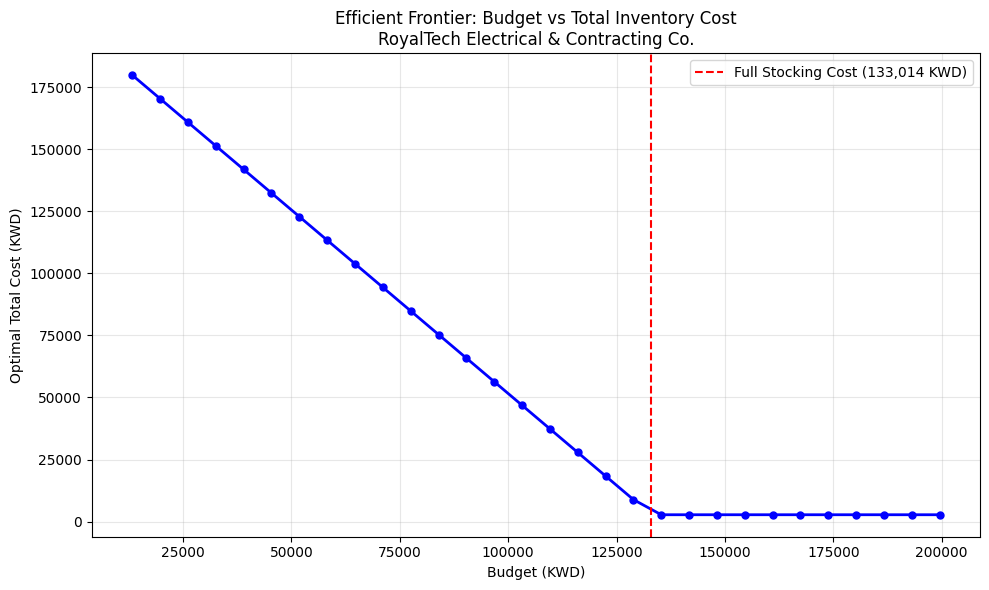

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(budgets_used, total_costs, 'b-o', markersize=5, linewidth=2)
plt.axvline(x=np.sum(procurement_cost * mean), color='r', linestyle='--', label='Full Stocking Cost (133,014 KWD)')
plt.xlabel('Budget (KWD)')
plt.ylabel('Optimal Total Cost (KWD)')
plt.title('Efficient Frontier: Budget vs Total Inventory Cost\nRoyalTech Electrical & Contracting Co.')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

# Baseline Comparison

To evaluate the practical value of the optimization approach, the optimized allocation is benchmarked against a uniform baseline strategy. The uniform baseline represents a naive allocation policy where the total budget is divided equally across all SKUs regardless of their individual demand levels, variability, or cost - essentially treating every SKU as equally important.

This is a realistic and meaningful baseline because it approximates how inventory decisions are often made in practice at small-to-medium businesses without formal optimization frameworks, spreading budget evenly across the product portfolio rather than concentrating it based on demand data.

The comparison is performed at the **50% budget level (66,507 KWD)** and evaluates:

*   **Baseline total cost:** Total holding + stockout cost under uniform allocation
*   **Optimized total cost:** Total holding + stockout cost under CVXPY optimal allocation
*   **Cost reduction:** Absolute and percentage improvement of the optimized approach over the baseline at the same budget level

The comparison is also visualized across all 30 budget levels to show that the optimized approach consistently outperforms the baseline at every point on the efficient frontier.





In [15]:
# Baseline: uniform allocation across all SKUs
q_baseline = np.full(n, Budget / np.sum(procurement_cost))

# Baseline total cost
holding_baseline = np.sum(holding_cost * q_baseline)
stockout_baseline = np.sum(stockout_penalty * np.maximum(mean - q_baseline, 0))
total_baseline = holding_baseline + stockout_baseline

# Optimized total cost at the same budget
problem_uniform, q_optimized_uniform = solve_inventory_optimization(Budget)
total_optimized = problem_uniform.value

print(f"Baseline vs Optimized Comparison (Budget: {Budget:,.3f} KWD)")
print(f"Baseline total cost: {total_baseline:,.3f} KWD")
print(f"Optimized total cost: {total_optimized:,.3f} KWD")
print(f"Cost reduction: {total_baseline - total_optimized:,.3f} KWD")
print(f"Improvement: {((total_baseline - total_optimized) / total_baseline * 100):,.2f}%")

Baseline vs Optimized Comparison (Budget: 66,507.315 KWD)
Baseline total cost: 130,686.238 KWD
Optimized total cost: 101,144.325 KWD
Cost reduction: 29,541.913 KWD
Improvement: 22.61%


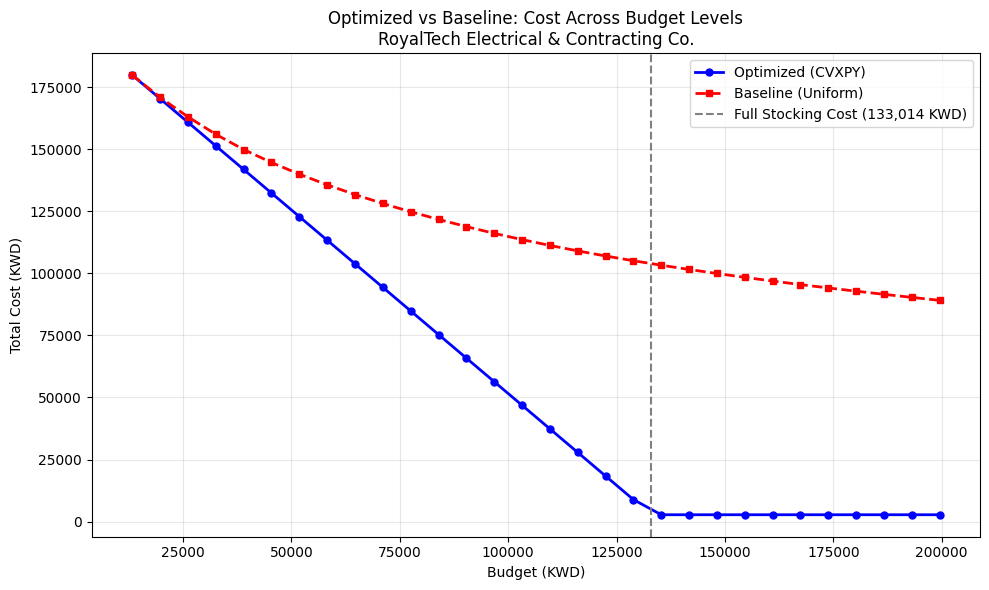

In [16]:
# Computing baseline cost across all budget levels
baseline_costs = []
for Budget_level in budgets_used:
  q_baseline = np.full(n, Budget_level / np.sum(procurement_cost))
  holding_baseline = np.sum(holding_cost * q_baseline)
  stockout_baseline = np.sum(stockout_penalty * np.maximum(mean - q_baseline, 0))
  baseline_costs.append(holding_baseline + stockout_baseline)

plt.figure(figsize=(10, 6))
plt.plot(budgets_used, total_costs, 'b-o', markersize=5, linewidth=2, label='Optimized (CVXPY)')
plt.plot(budgets_used, baseline_costs, 'r--s', markersize=5, linewidth=2, label='Baseline (Uniform)')
plt.axvline(x=np.sum(procurement_cost * mean), color='gray', linestyle='--', label='Full Stocking Cost (133,014 KWD)')
plt.xlabel('Budget (KWD)')
plt.ylabel('Total Cost (KWD)')
plt.title('Optimized vs Baseline: Cost Across Budget Levels\nRoyalTech Electrical & Contracting Co.')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('baseline_vs_optimized.png', dpi=150, bbox_inches='tight')
plt.show()

# SKU-Level Results

In [17]:
results_df = main_df[['sku_code', 'product_name', 'mean_demand', 'avg_landed_cost']].copy()
results_df['baseline_qty'] = q_baseline
results_df['optimal_qty'] = q_optimized_uniform.value
results_df['qty_adjustment'] = results_df['optimal_qty'] - results_df['baseline_qty']
results_df['action'] = results_df['qty_adjustment'].apply(lambda x: 'Increase Stock' if x > 0 else 'Decrease Stock')

print(f"Results dataframe shape: {results_df.shape}")
print(f"SKUs to Increase Stock: {len(results_df[results_df['action'] == 'Increase Stock'])}")
print(f"SKUs to Decrease Stock: {len(results_df[results_df['action'] == 'Decrease Stock'])}")

print("\n--- Top 10 SKUs to Increase Stock ---")
print(results_df[results_df['action'] == 'Increase Stock'].nlargest(10, 'qty_adjustment')[
    ['sku_code', 'product_name', 'mean_demand', 'baseline_qty', 'optimal_qty', 'qty_adjustment']
])

print("\n--- Top 10 SKUs to Decrease Stock ---")
print(results_df[results_df['action'] == 'Decrease Stock'].nsmallest(10, 'qty_adjustment')[
    ['sku_code', 'product_name', 'mean_demand', 'baseline_qty', 'optimal_qty', 'qty_adjustment']
])

# Saving the results dataframe to CSV
results_df.to_csv('sku_optimization_results.csv', index=False)
main_df.to_csv('main_parameters.csv', index=False)

Results dataframe shape: (3856, 8)
SKUs to Increase Stock: 1011
SKUs to Decrease Stock: 2845

--- Top 10 SKUs to Increase Stock ---
     sku_code                      product_name  mean_demand  baseline_qty  \
599    101506             SADDLE GI BARTON 25MM  2870.379310     15.495654   
1462   104154  TUBE 2FT OSRAM 18W DAY LIGHT 765  2362.631579     15.495654   
2607   110338     CABLE SCREENED 2.5MMX3C KUWES  1645.833333     15.495654   
2434   109353                ADAPTOR STEEL 25MM  1557.000000     15.495654   
1706   105183                    SADDLE GI 25MM  1778.777778     15.495654   
3547   113463             TUBE 2FT SURYA 20W DL  1313.000000     15.495654   
452    101165        MALE BUSH BRASS 25MM SHORT  1265.103448     15.495654   
1576   104663                        NUT GI 8MM  1517.178571     15.495654   
1461   104153  TUBE 4FT OSRAM 36W/765 DAY LIGHT   980.977273     15.495654   
684    101806   TAPE INSULATION VINI JAPAN 3/4"  1055.880682     15.495654   

      opt

# Save Outputs

In [18]:
# Saving plots and results to Google Drive
drive_path = '/content/drive/MyDrive/UMD Spring-26/MSML 604/Project/'

shutil.copy('efficient_frontier.png', drive_path + 'efficient_frontier.png')
shutil.copy('baseline_vs_optimized.png', drive_path + 'baseline_vs_optimized.png')
shutil.copy('sku_optimization_results.csv', drive_path + 'sku_optimization_results.csv')
shutil.copy('main_parameters.csv', drive_path + 'main_parameters.csv')

print("All files saved to Google Drive")

All files saved to Google Drive
